In [23]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/SW엔지니어


### 목표
- mip, cnn 모델을 활용하여 이미지 분류 실습 진행해보자
- 이진 분류
-성능을 높이기 위한 방법들을 진행해보자
  - 이미지 증식(확장)
  - 전이학습

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# 데이터 불러오기
data = np.load('./data/np_cat_vs_dog.npz')

In [26]:
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# 확인
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2000, 224, 224, 3) (1000, 224, 224, 3) (2000,) (1000,)


MLP(다층퍼셉트론) 모델링 수행
1. 신경망 구조 설계
2. 학습 방법 설정
3. 학습
4. 시각화

In [27]:
# 환경세팅을 위한 라이브러리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
# 1. 설계
mlp_model = Sequential()

#mlp_model.add(InputLayer(shape = (224.224.3)))
#mlp_model.add(Flatten())
mlp_model.add(Flatten(input_shape=(224,224,3)))

mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dense(64, activation='relu'))

mlp_model.add(Dense(1, activation='sigmoid'))

# 2. 학습방법 설정
mlp_model.compile(optimizer='adam', # 최적화함수
                  loss='binary_crossentropy', metrics=['accuracy'])

# 조기학습중단
early = EarlyStopping(monitor='val_accuracy', patience=5, verbose = 1) # 모델 개선 없을 시, 5번까지 반복 후 종료

# 학습
# 조기학습 중단 연결
mlp_his = mlp_model.fit(X_train, y_train, validation_split=0.3, epochs=40, callbacks=[early], # 조기 학습 중단
                        verbose = 1 # 진행상황 표시
                        )

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.5694 - loss: 1916.4438 - val_accuracy: 0.0000e+00 - val_loss: 14053.2480
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6433 - loss: 2423.3281 - val_accuracy: 0.0067 - val_loss: 1230.1034
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6783 - loss: 200.9898 - val_accuracy: 0.0367 - val_loss: 503.1203
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6690 - loss: 171.0911 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5662 - loss: 580.5232 - val_accuracy: 0.1250 - val_loss: 254.0299
Epoch 6/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6975 - loss: 76.1108 - val_accuracy: 0.2350 - val_loss: 167.0197
Epoch 7/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6434 - loss: 102.8868 - val_accuracy: 0.0000e+00 - val_loss: 679.6883
Epoch 8/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6298

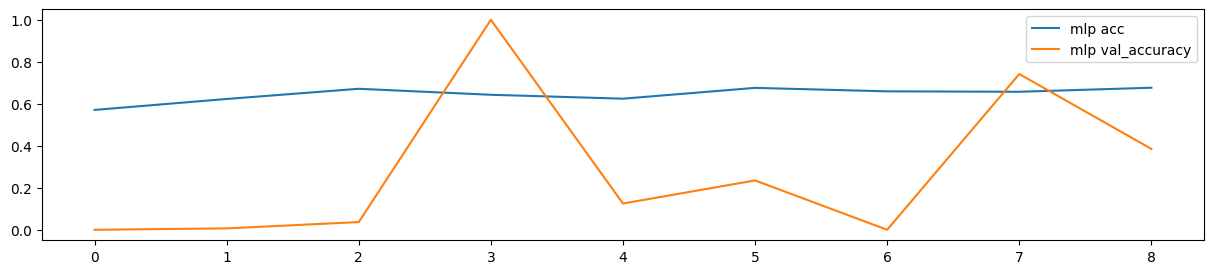

In [29]:
# mlp_his 시각화
plt.figure(figsize=(15,3))

plt.plot(mlp_his.history['accuracy'], label='mlp acc')
plt.plot(mlp_his.history['val_accuracy'], label='mlp val_accuracy')
plt.legend()
plt.show()

In [30]:
# 모델이 학습자체를 제대로 하지 못한 상황
# 복잡한 데이터, 모델 단순한 상황
# mlp 특성상 이미지에 대한 학습 성능 떨어짐
# 이미지에 대한 파악을 잘 할 수 있게 해보자 -> 중요한 특성 추출 학습 -> cnn

#### CNN 모델 생성
1. 모델 설계
  - 뼈대 구축
  - 특성 추출부(합성곱)
  - 분류부
2. 모델 컴파일
3. 학습 및 시각화
4. 예측 및 평가


필요한 라이브러리 import




In [31]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, InputLayer,Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

# Con2D : 특징을 잡아내는 역할(컨볼루셔널 레이어)
# MaxPooling2D : 중요한 정보만 걸러내는 역할(풀링 레이어)

In [32]:
# 1. 설계
cnn_model = Sequential()

cnn_model.add(InputLayer(input_shape=(224,224,3)))

# -------------- 특징 추출부 ---------
cnn_model.add(Conv2D(
  filters = 32, # 커널의 개수 # 탐지할 눈의 개수
  kernel_size = (3,3), # 커널의 사이즈 # 탐지하는 눈의 크기
  activation = 'relu',
  padding = 'same', # 패딩 : 입출력의 크기를 동일하게 하기 위해 가장자리에 0을 세우겠다
                   # 이미지 차체가 작거나, 가장자리에 중요한 정보가 있는 경우 : same
                   # 이미지 자체가 크거나, 특징이 많을 때 : valid # 커널이 밖으로 못나감
  strides = (2,2) # 보폭, 커널이 양 옆과 위 아래로 2픽셀씩 이동 /// 커널의 보폭

))

cnn_model.add(MaxPooling2D(
    pool_size = (2,2) # 플링 윈도우 지정
    # 이미지 탐색에서 그 이미지의 특정 위치의 특징을 요약하는 픽셀 크기 지정
))

cnn_model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding = 'same', strides = (2,2)))
cnn_model.add(MaxPooling2D(pool_size = (2,2)))
cnn_model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = 'same', strides = (2,2)))
cnn_model.add(MaxPooling2D(pool_size = (2,2)))

# ---------------분류부-----------

cnn_model.add(Flatten()) # 자원 축소
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(64, activation='relu'))

# 출력층
cnn_model.add(Dense(1, activation='sigmoid'))

# 2. 학습방법 설정
cnn_model.compile(optimizer='adam', # 최적화함수
                  loss='binary_crossentropy', metrics=['accuracy'])

# 3. 학습

cnn_his = cnn_model.fit(X_train, y_train, validation_split=0.3, epochs=20, batch_size = 64,
                        verbose = 1
                        )


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 284ms/step - accuracy: 0.5723 - loss: 5.9959 - val_accuracy: 0.0083 - val_loss: 1.6922
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7064 - loss: 0.6142 - val_accuracy: 0.0233 - val_loss: 1.2719
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7423 - loss: 0.5468 - val_accuracy: 0.2600 - val_loss: 1.0332
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7414 - loss: 0.5264 - val_accuracy: 0.0967 - val_loss: 1.4246
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7638 - loss: 0.4837 - val_accuracy: 0.5350 - val_loss: 0.7948
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7874 - loss: 0.4456 - val_accuracy: 0.3017 - val_loss: 1.3304
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8254 - loss: 0.4078 - val_accuracy: 0.1900 - val_loss: 1.6751
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8561 - loss: 0.3478 - val_accuracy: 0.3950 -

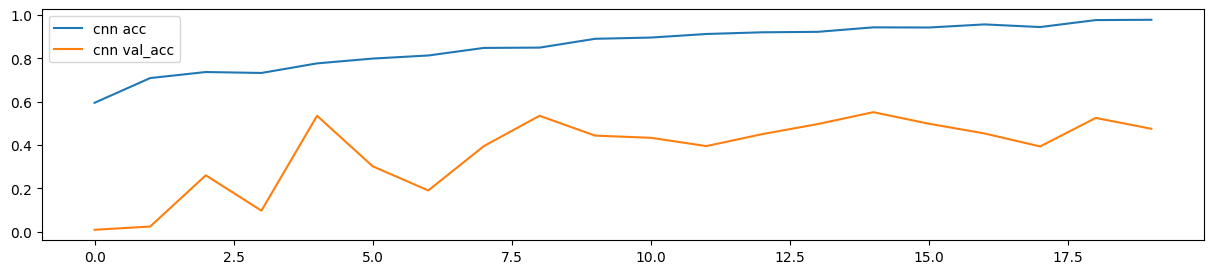

In [33]:
# 시각화
# cnn_his 시각화
plt.figure(figsize=(15,3))

plt.plot(cnn_his.history['accuracy'], label='cnn acc')
plt.plot(cnn_his.history['val_accuracy'], label='cnn val_acc')
plt.legend()
plt.show()

In [34]:
# 성능의 일반화가 mip보다는 더 된건 사실이지만,
# train에 대해 너무 맞춰서 학습하는 과대적합 현상이 심화됨
# 과대적합을 해소하면서, 모델의 일반화 성능을 더 높여야합니다.

#### 데이터 이미지 증강(증식, 확장)을 통환 cnn모델 성능 개선
- 데이터 증강 : 이미지 회전, 이동, 확대, 축소 등을 통해
데이터를 늘리는 작업
- 과대적합이 일어나는 이유 중 하나는 훈련데이터가 부족
- 훈련데이터가 충분히 많다면, 과대적합을 줄일 수 있음.
- 데이터 확장이랑 훈련데이터를 다양하게 변형하여 변형된 새로운 훈련데이터를 사용하므로써 마치 훈련데이터 수가 늘어난 효과를 얻는 것

** 주의사항
- 증강은 '훈련 데이터'에서만 진행


In [35]:
# 이미지 크기 조절, 픽셀값 변경, 라벨링, 이미지 데이터 증강 라이브러리
from tensorflow.keras.preprocessing.image import ImageDataGenerator

| 옵션               | 설명                                                       |
|--------------------|------------------------------------------------------------|
| `rescale`          | 입력 이미지의 픽셀 값 재조정(ex.rescale=1.255 -> 모든 픽셀값들에 대해 0~1 사이로 정규화)|
| `rotation_range`   | 이미지의 회전 범위를 설정(ex.rotation_range -> -20~20도 사이에서 무작위로 회전)|
| `width_shift_range`| 이미지의 수평 이동 범위를 설정(ex.0.1은 전체 너비의 10%만큼 좌우로 무작위로 이동) |
| `height_shift_range`| 이미지의 수직 이동 범위를 설정(ex.0.1은 전체 너비의 10%만큼 위아래로 무작위로 이동)|
| `shear_range`      | 시계 반대 방향으로 지정된 각도만큼 변형       |
| `zoom_range`       | 이미지의 확대 및 축소 범위를 설정(ex.0.1 -> 0.9배~1.1배 사이에서 무작위로 확대하거나 축소) |
| `horizontal_flip`  | 이미지를 수평 방향으로 뒤집을지 여부를 설정       |
| `fill_mode`        | 이미지를 변형할 때 생기는 빈 공간을 채우는 방식을 설정(ex.nearest -> 가장 가까운 픽셀값을 사용하여 빈공간 채우기) |


In [ ]:
ㅁㅅ

In [44]:
# 증강할 데이터 경로 설정
train_dir = './data/cats_and_dogs_filtered/train'
test_dir = './data/cats_and_dogs_filtered/test'

# 증강기 생성(변형할 형식 지정)
train_gen = ImageDataGenerator(
    rescale=1./255, # 이미지의 픽셀 값을 0~1 범위로 스케일링
    zoom_range = 0.2, # 0.8배(감소) ~ 1.2배(확대) 축소 및 확대
    horizontal_flip = True # 좌우 반전

)

test_gen = ImageDataGenerator(rescale=1./255)

In [45]:
# 이미지 데이터 제너레이터 생성
# flow_from_directory
# 지정된 디렉토리에서 이미지를 불러오고, 실시간으로 데이터를 생성하는 기능
train_generator = train_gen.flow_from_directory(
    train_dir, # 이미지가 저
    target_size = (224,224), #이미지들의 크기 고정
    batch_size = 32, # 한번에 변환할 이미지 개수
    class_mode = 'binary' # 이진 분류 / categorical : 다중분류
)

test_generator = test_gen.flow_from_directory(
    test_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


'./data/cats_and_dogs_filtered/train'

### Dropout

- 과대적합을 개선
- 학습하는 동안에만 적용
- 신경망을 비율에 따라 활성화 되지 않도록 꺼버림

In [40]:
# Dropout 임포트
from tensorflow.keras.layers import Dropout

In [47]:
# 1. 설계
cnn_model2 = Sequential()

cnn_model2.add(InputLayer(input_shape=(224,224,3)))

# -------------- 특징 추출부 ---------
cnn_model2.add(Conv2D(
  filters = 32,
  kernel_size = (3,3),
  activation = 'relu',
  padding = 'same',
  strides = (2,2)
))

cnn_model2.add(MaxPooling2D(
    pool_size = (2,2) # 플링 윈도우 지정
    # 이미지 탐색에서 그 이미지의 특정 위치의 특징을 요약하는 픽셀 크기 지정
))

#########
cnn_model2.add(Dropout(0.3))
# pool층에 의해 나온 특징지도(피쳐맵) 중 30% 무작위로 0으로 만든 후 두번째 층으로 넘김
# 예측을 수행할 때는 비활성화

cnn_model2.add(Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding = 'same', strides = (2,2)))
cnn_model2.add(MaxPooling2D(pool_size = (2,2)))

cnn_model2.add(Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = 'same', strides = (2,2)))
cnn_model2.add(MaxPooling2D(pool_size = (2,2)))

#########
cnn_model2.add(Dropout(0.3))


# ---------------분류부-----------

cnn_model2.add(Flatten()) # 자원 축소
cnn_model2.add(Dense(256, activation='relu'))

#########
cnn_model2.add(Dropout(0.3))

cnn_model2.add(Dense(128, activation='relu'))
cnn_model2.add(Dense(64, activation='relu'))

# 출력층
cnn_model2.add(Dense(1, activation='sigmoid'))

# 2. 학습방법 설정
cnn_model2.compile(optimizer='adam', # 최적화함수
                  loss='binary_crossentropy', metrics=['accuracy'])

# 3. 학습

cnn_his2 = cnn_model2.fit(#X_train, y_train,
                        train_generator, # 이미지 증강 적용
                        #validation_split=0.3,
                        validation_data = test_generator,
                        # spilt으로 할 경우, 증강이 적용되기 때문에, 별도의 검증용 데이터셋으로 진행하기를 권장(지금은 test데이터를 사용)

                        epochs=20, batch_size = 64,
                        verbose = 1
                        )


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1990s 32s/step - accuracy: 0.5053 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 586ms/step - accuracy: 0.5191 - loss: 0.6934 - val_accuracy: 0.5020 - val_loss: 0.6922
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 590ms/step - accuracy: 0.5192 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6949
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 573ms/step - accuracy: 0.5216 - loss: 0.6908 - val_accuracy: 0.5250 - val_loss: 0.6864
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 576ms/step - accuracy: 0.5710 - loss: 0.6797 - val_accuracy: 0.5700 - val_loss: 0.6751
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 568ms/step - accuracy: 0.5938 - loss: 0.6700 - val_accuracy: 0.5980 - val_loss: 0.6552
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 566ms/step - accuracy: 0.6255 - loss: 0.6448 - val_accuracy: 0.6380 - val_loss: 0.6224
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 583ms/step - accuracy: 0.6236 - loss: 0.6429 - val_accu

시각화 코드

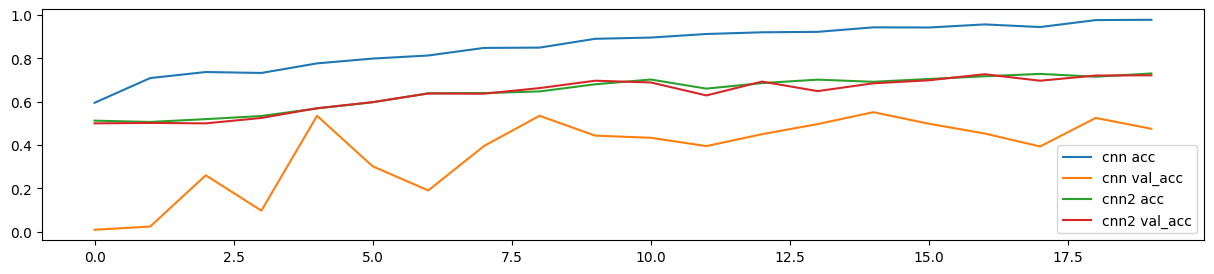

In [50]:
# 시각회
# cnn_his, cnn_hos2 시각화
plt.figure(figsize=(15,3))

plt.plot(cnn_his.history['accuracy'], label='cnn acc')
plt.plot(cnn_his.history['val_accuracy'], label='cnn val_acc')

plt.plot(cnn_his2.history['accuracy'], label='cnn2 acc')
plt.plot(cnn_his2.history['val_accuracy'], label='cnn2 val_acc')
plt.legend()
plt.show()

In [48]:
# 이미지 증식을 통해 나름대로 과대적합 해소된 것을 확인 할 수 있음(예정)
# 이미지 증식으로 모델 성능 개선
# 이미지 증식 단점 : 학습 시간이 오래 걸림

### 전이학습
- 다른 사람이 만들어 놓은 모델을 사용해보자

In [49]:
from tensorflow.keras.applications import VGG16
# 1000개 다중분류

In [51]:
vgg16=VGG16(include_top=False, weights = 'imagenet',
            input_shape = (224,224,3))
# top : 분류분기층, vgg16모델은 다중분류(1000개)이므로 사용하지 않는다(분류층 따로 진행할 예정)
# weights : 'imagenet' -> 기존 학습한 가중치 불러옴

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [52]:
# 모든 conv층 동결, 가중치 갱신 막아야함 -> 학습 불가능하게 설정
# vgg16은 100만장이상의 사진으로 학습이 되어있음. 성능이 좋음

# 특성 추출부 고정
for layer in vgg16.layers:
  layer.trainable = False # 훈련가능성 없음

In [53]:
transfer_model = Sequential()
transfer_model.add(vgg16)

# 분류기층 -> mip(이진분류 : 개 vs 고양이)
transfer_model.add(Flatten())
transfer_model.add(Dense(64, activation='relu'))

transfer_model.add(Dense(1, activation='sigmoid'))


In [54]:
# 학습/평가 방법 설정
transfer_model.compile(optimizer='adam',# 최적화 함수
                       loss='binary_crossentropy', metrics=['accuracy'])

In [55]:
transfer_model_history = transfer_model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = 10,
    verbose = 1,
    batch_size = 64
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6623 - loss: 1.0018 - val_accuracy: 0.9060 - val_loss: 0.2522
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 648ms/step - accuracy: 0.8874 - loss: 0.2643 - val_accuracy: 0.9120 - val_loss: 0.2226
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 649ms/step - accuracy: 0.9362 - loss: 0.1857 - val_accuracy: 0.9090 - val_loss: 0.2038
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 715ms/step - accuracy: 0.9478 - loss: 0.1606 - val_accuracy: 0.9020 - val_loss: 0.2084
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 647ms/step - accuracy: 0.9303 - loss: 0.1741 - val_accuracy: 0.9170 - val_loss: 0.2109
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 642ms/step - accuracy: 0.9490 - loss: 0.1350 - val_accuracy: 0.9280 - val_loss: 0.1828
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 643ms/step - accuracy: 0.9593 - loss: 0.1082 - val_accuracy: 0.9240 - val_loss: 0.1927
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 633ms/step - accuracy: 0.9769 - loss: 0.0844 - val_accurac

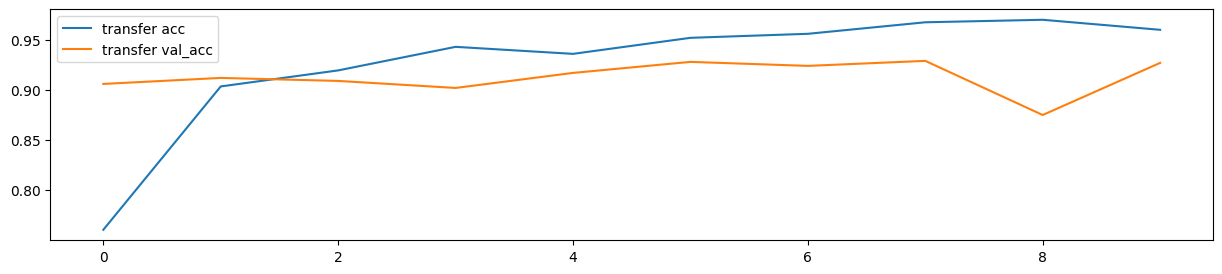

In [60]:
# 시각화
# vgg16 모델 전이학습 시각화
plt.figure(figsize=(15,3))

plt.plot(transfer_model_history.history['accuracy'], label='transfer acc')
plt.plot(transfer_model_history.history['val_accuracy'], label='transfer val_acc')
plt.legend()
plt.show()